In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [2]:
df=pd.read_csv('../data/bank-marketing-cleaned.csv')

In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,Unknown,261,1,-1,0,0
1,44,technician,single,secondary,no,29,yes,no,Unknown,151,1,-1,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,Unknown,76,1,-1,0,0
3,47,blue-collar,married,Unknown,no,1506,yes,no,Unknown,92,1,-1,0,0
4,33,blue-collar,single,Unknown,no,1,no,no,Unknown,198,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,977,3,-1,0,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,456,2,-1,0,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,1127,5,184,3,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,508,4,-1,0,0


In [4]:
df.drop(['duration'],axis=1,inplace=True)

## Feature Engineering

In [5]:
print(df.select_dtypes(include='object').nunique())


job          11
marital       3
education     4
default       2
housing       2
loan          2
contact       3
dtype: int64


In [6]:
y=df['y'].copy()
X=df.drop(['y'],axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True,stratify=y)

In [7]:
transformer = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(drop='first'),['job','marital','default','housing','loan','contact','education'])],
                                remainder='passthrough')
scaler =ColumnTransformer(transformers=[
    (('stdsc',StandardScaler(),slice(0,11)))
])

## Model Selection
- Logistic Regression - Base Model(class_weight=balanced)
- Decision Tree Classifier -- Improved Model
- Random Forest Classifier -- (Bagging Model)
- Gradient Boosting Classifier -- (Boosting Model)

In [13]:
log_trf = LogisticRegression(solver='saga',
                             C=0.01,max_iter=1000,class_weight="balanced",penalty='l1')
pipe = Pipeline([
    ('trf1',transformer), #encoding
    ('log_trf',log_trf) # model
    ])

In [14]:
pipe.fit(X_train,y_train)

d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('trf1', ...), ('log_trf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will

In [15]:
y_pred =pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
f1 = np.divide(
    2 * (precision * recall),
    (precision + recall),
    out=np.zeros_like(precision),
    where=(precision + recall) != 0)
best_threshold = thresholds[np.argmax(f1)]
y_pred = (y_prob > best_threshold).astype(int)
print(classification_report(y_test,y_pred,zero_division=1.0))

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      9981
           1       0.20      0.48      0.28      1322

    accuracy                           0.72     11303
   macro avg       0.56      0.61      0.55     11303
weighted avg       0.83      0.72      0.76     11303



<Axes: >

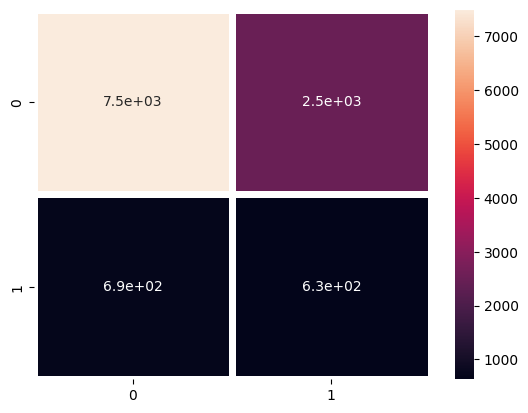

In [16]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,linewidths=5)

In [17]:
best_threshold

np.float64(0.49836778469083975)

In [10]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
params ={
    'log_trf__solver':['lbfgs','liblinear','saga','newton-cg'],
    'log_trf__penalty':['l2','l1','elasticnet'],
    'log_trf__max_iter':[100,500,1000],
    'log_trf__C':[0.001,0.01,0.1,10],
}
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(
    estimator=pipe,param_distributions=params,n_iter=20,cv=cv,n_jobs=-1,random_state=42,verbose=2
)
random.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\imblearn\pipeline.py", 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...newton-cg'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'log_trf__C': [0.001, 0.01, ...], 'log_trf__max_iter': [100, 500, ...], 'log_trf__penalty': ['l2', 'l1', ...], 'log_trf__solver': ['lbfgs', 'liblinear', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [18]:
best_model = random.best_estimator_

(random.best_params_)

{'log_trf__solver': 'saga',
 'log_trf__penalty': 'l1',
 'log_trf__max_iter': 1000,
 'log_trf__C': 0.01}

In [19]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6300725917821773


In [20]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.16984087639841614


Text(0.5, 1.0, 'Calibration Curve')

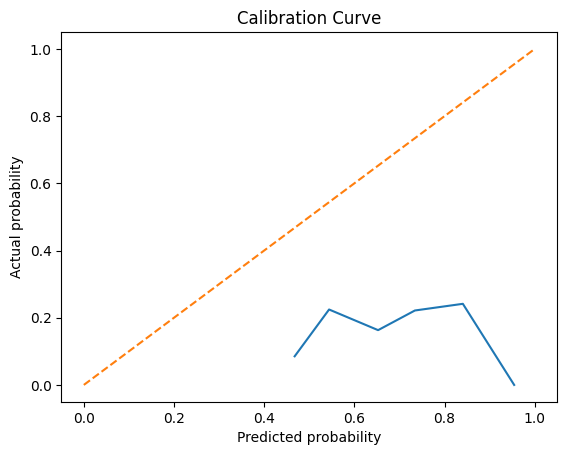

In [21]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve")

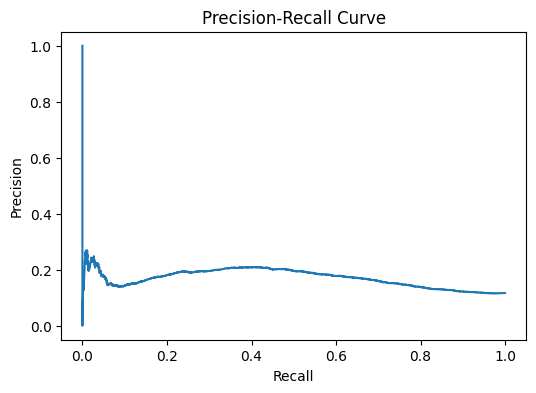

In [22]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [23]:

import pickle
pickle.dump(pipe,open('logistic.pkl','wb'))

## Decision Tree Classifier

In [27]:

dt_trf=DecisionTreeClassifier(splitter='best',min_samples_split=20,
                              min_samples_leaf=2,max_depth=7,criterion='gini',
                              class_weight='balanced',ccp_alpha=0.0001)
pipe1 = Pipeline([
    ('trf1',transformer), #encoding
    ('dt_trf',dt_trf) # model
    ])
pipe1.fit(X_train,y_train)
y_pred_dt = pipe1.predict(X_test)
print(classification_report(y_test,y_pred_dt))


              precision    recall  f1-score   support

           0       0.93      0.74      0.82      9981
           1       0.24      0.61      0.34      1322

    accuracy                           0.72     11303
   macro avg       0.58      0.67      0.58     11303
weighted avg       0.85      0.72      0.77     11303



In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
params ={
    "dt_trf__criterion": ["gini", "entropy", "log_loss"],
    "dt_trf__splitter": ["best", "random"],
    "dt_trf__max_depth": [3,5,7,10,15,20],
    "dt_trf__min_samples_split": [2,5,10,20],
    "dt_trf__min_samples_leaf": [1,2,5,10],
    "dt_trf__max_features": [None, "sqrt", "log2"],
    "dt_trf__class_weight": [None, "balanced"],
    "dt_trf__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005]

}
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(
    estimator=pipe1,param_distributions=params,n_iter=20,cv=cv,n_jobs=-1,random_state=42,verbose=2,scoring='f1'
)
random.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...s_split=20))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'dt_trf__ccp_alpha': [0.0, 0.0001, ...], 'dt_trf__class_weight': [None, 'balanced'], 'dt_trf__criterion': ['gini', 'entropy', ...], 'dt_trf__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validatio

In [28]:
random.best_estimator_
random.best_params_

{'dt_trf__splitter': 'best',
 'dt_trf__min_samples_split': 20,
 'dt_trf__min_samples_leaf': 2,
 'dt_trf__max_features': None,
 'dt_trf__max_depth': 7,
 'dt_trf__criterion': 'gini',
 'dt_trf__class_weight': 'balanced',
 'dt_trf__ccp_alpha': 0.0001}

In [29]:
pipe1.named_steps["dt_trf"].feature_importances_

array([0.00493368, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00108079, 0.        , 0.00297155, 0.        ,
       0.01594475, 0.04726871, 0.        , 0.14733767, 0.0080765 ,
       0.1546996 , 0.01993575, 0.00165529, 0.        , 0.        ,
       0.14351925, 0.08051453, 0.02894081, 0.33540054, 0.00772058])

In [30]:
y_pred =pipe1.predict(X_test)
y_prob = pipe1.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
f1 = np.divide(
    2 * (precision * recall),
    (precision + recall),
    out=np.zeros_like(precision),
    where=(precision + recall) != 0)
best_threshold = thresholds[np.argmax(f1)]
y_pred = (y_prob > best_threshold).astype(int)
print(classification_report(y_test,y_pred,zero_division=1.0))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      9981
           1       0.40      0.38      0.39      1322

    accuracy                           0.86     11303
   macro avg       0.66      0.65      0.65     11303
weighted avg       0.86      0.86      0.86     11303



In [31]:
best_threshold

np.float64(0.6646744063135271)

In [32]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.3259668156953489


Text(0.5, 1.0, 'Calibration Curve')

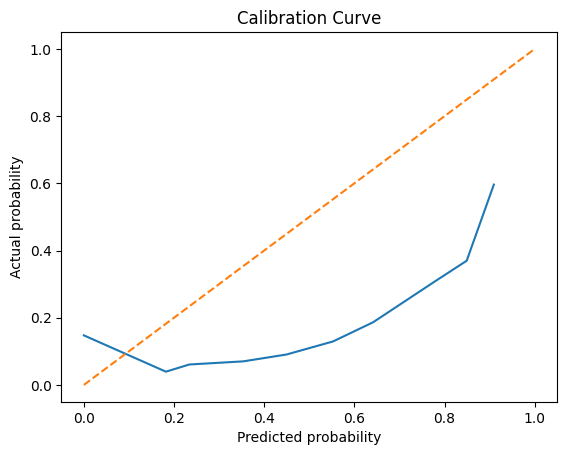

In [33]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve")

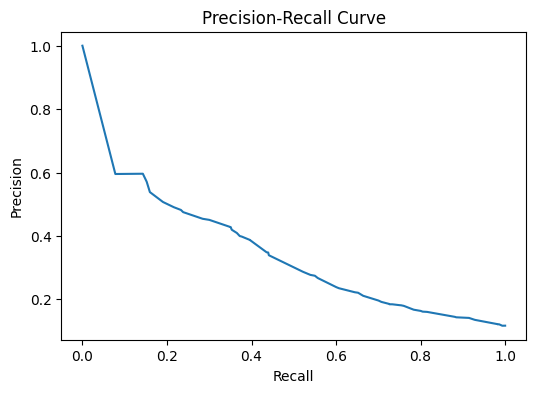

In [34]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [35]:
pickle.dump(pipe1,open("decision_tree.pkl","wb"))

## Random Forest Classifier

In [38]:
rf_trf=RandomForestClassifier(oob_score=True,random_state=42,max_depth=15,class_weight='balanced',
                              n_estimators=500,criterion='entropy',min_samples_leaf=1,n_jobs=-1,
                              ccp_alpha=0.0,min_samples_split=10,min_impurity_decrease=0.01,
                              max_features='sqrt')
pipe_rf = Pipeline([
    ('trf1',transformer), #encoding
    ('rf_trf',rf_trf) # model
    ])
pipe_rf.fit(X_train,y_train)
y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.68      0.79      9981
           1       0.21      0.66      0.32      1322

    accuracy                           0.68     11303
   macro avg       0.58      0.67      0.56     11303
weighted avg       0.85      0.68      0.73     11303



In [37]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
params ={
    "rf_trf__criterion": ["gini", "entropy", "log_loss"],
    "rf_trf__max_depth": [3,5,7,10,15,20],
    "rf_trf__min_samples_split": [2,5,10,20],
    "rf_trf__min_samples_leaf": [1,2,5,10],
    "rf_trf__max_features": [None, "sqrt", "log2","float"],
    "rf_trf__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "rf_trf__n_estimators":[100,200,500,1000],
    "rf_trf__max_samples":['int','float',None],
    "rf_trf__oob_score":[True,False],
    "rf_trf__oob_score":[True],
    "rf_trf__min_impurity_decrease":[000.1,0.005,0.1,0.01],
    "rf_trf__class_weight":[None,'balanced']
}

from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(
    estimator=pipe_rf,param_distributions=params,n_iter=20,cv=cv,n_jobs=-1,random_state=42,verbose=2,scoring='f1'
)
random.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
70 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\imblearn\pipeline.py", 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf_trf__ccp_alpha': [0.0, 0.0001, ...], 'rf_trf__class_weight': [None, 'balanced'], 'rf_trf__criterion': ['gini', 'entropy', ...], 'rf_trf__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validatio

In [39]:
random.best_estimator_
random.best_params_

{'rf_trf__oob_score': True,
 'rf_trf__n_estimators': 500,
 'rf_trf__min_samples_split': 10,
 'rf_trf__min_samples_leaf': 1,
 'rf_trf__min_impurity_decrease': 0.01,
 'rf_trf__max_samples': None,
 'rf_trf__max_features': 'sqrt',
 'rf_trf__max_depth': 15,
 'rf_trf__criterion': 'entropy',
 'rf_trf__class_weight': 'balanced',
 'rf_trf__ccp_alpha': 0.0}

In [40]:

y_pred =pipe_rf.predict(X_test)
y_prob = pipe_rf.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
f1 = np.divide(
    2 * (precision * recall),
    (precision + recall),
    out=np.zeros_like(precision),
    where=(precision + recall) != 0)
best_threshold = thresholds[np.argmax(f1)]
y_pred = (y_prob > best_threshold).astype(int)
print(classification_report(y_test,y_pred,zero_division=1.0))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      9981
           1       0.39      0.31      0.34      1322

    accuracy                           0.86     11303
   macro avg       0.65      0.62      0.63     11303
weighted avg       0.85      0.86      0.85     11303



In [41]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.30231111863262305


Text(0.5, 1.0, 'Calibration Curve')

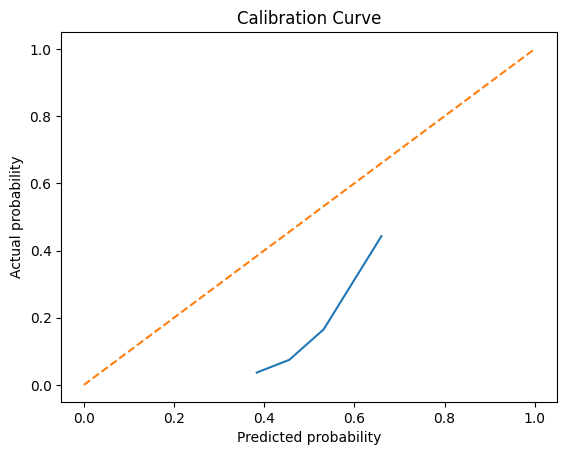

In [42]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve")

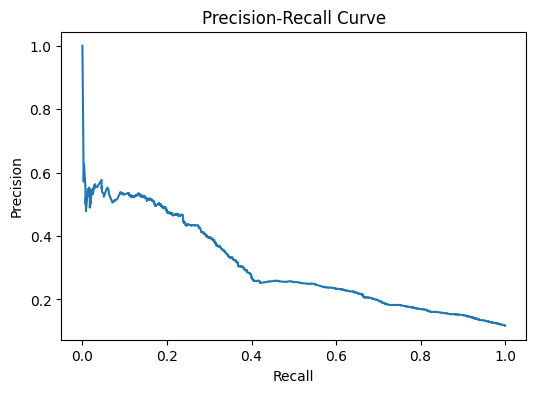

In [43]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

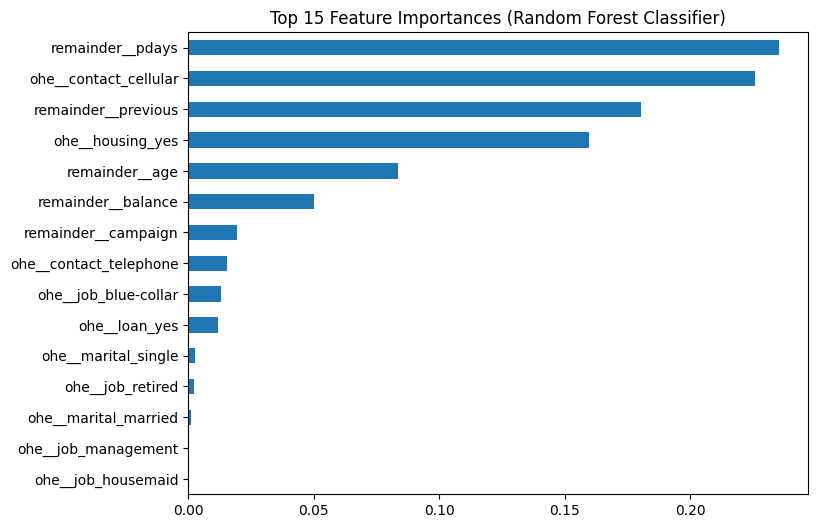

In [44]:
importances = pipe_rf.named_steps['rf_trf'].feature_importances_

feature_names = pipe_rf.named_steps['trf1'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances (Random Forest Classifier)")
plt.gca().invert_yaxis()
plt.show()

In [45]:
pickle.dump(pipe_rf,open('rf-pipeline.pkl','wb'))

## Gradient Boosting Classifier

In [51]:
from sklearn.ensemble import GradientBoostingClassifier
gb_trf=GradientBoostingClassifier(random_state=42,loss='log_loss',
                              n_estimators=500,criterion='friedman_mse',min_samples_leaf=1,
                              ccp_alpha=0.0001,min_samples_split=20,
                              max_depth=7,min_impurity_decrease=0.01,max_features='log2',verbose=2,validation_fraction=0.5,
                             subsample= 0.5)
pipe_gb = Pipeline([
    ('trf1',transformer), #encoding
    ('gb_trf',gb_trf) # model
    ])
from sklearn.utils import compute_sample_weight

train_weights=compute_sample_weight(class_weight='balanced',y=y_train)
pipe_gb.fit(X_train,y_train,gb_trf__sample_weight=train_weights)
y_pred_gb = pipe_gb.predict(X_test)
print(classification_report(y_test,y_pred_gb))

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3534           0.0280            6.49s
         2           1.3292           0.0197            6.97s
         3           1.3116           0.0260            6.96s
         4           1.2903           0.0179            6.57s
         5           1.2742           0.0147            6.24s
         6           1.2568           0.0144            6.01s
         7           1.2494           0.0155            5.88s
         8           1.2303           0.0042            5.75s
         9           1.2275           0.0154            5.71s
        10           1.2222           0.0117            5.57s
        11           1.2021           0.0008            5.54s
        12           1.2029           0.0175            5.55s
        13           1.1924           0.0011            5.49s
        14           1.1885           0.0080            5.44s
        15           1.1762          -0.0015            5.35s
       

In [48]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
params ={
    "gb_trf__criterion": ["friedman_mse", "squared_error"],
    "gb_trf__max_depth": [3,5,7,10,12],
    "gb_trf__min_samples_split": [2,5,10,20],
    "gb_trf__min_samples_leaf": [1,2,5,10],
    "gb_trf__max_features": [None, "sqrt", "log2"],
    "gb_trf__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "gb_trf__n_estimators":[100,200,500,1000],
    "gb_trf__subsample":[0.5,0.7,0.8],
    "gb_trf__min_impurity_decrease":[000.1,0.005,0.1,0.01],
    "gb_trf__learning_rate":[0.01,0.02,0.05]
}
from sklearn.utils import compute_sample_weight
train_weights=compute_sample_weight(class_weight='balanced',y=y_train)

from sklearn.model_selection import RandomizedSearchCV
randomgb = RandomizedSearchCV(
    estimator=pipe_gb,param_distributions=params,n_iter=20,cv=cv,n_jobs=-1,random_state=42,verbose=2,scoring='f1'
)
randomgb.fit(X_train,y_train,gb_trf__sample_weight=train_weights)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3799           0.0056            5.49s
         2           1.3735           0.0051            6.49s
         3           1.3684           0.0067            6.47s
         4           1.3624           0.0053            6.33s
         5           1.3574           0.0052            6.05s
         6           1.3515           0.0054            6.02s
         7           1.3485           0.0048            5.92s
         8           1.3416           0.0028            5.91s
         9           1.3383           0.0071            5.84s
        10           1.3339           0.0050            5.79s
        11           1.3261           0.0028            5.78s
        12           1.3240           0.0081            5.84s
        13           1.3183           0.0019            5.79s
        14           1.3147           0.0058            5.78s
       

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=2))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'gb_trf__ccp_alpha': [0.0, 0.0001, ...], 'gb_trf__criterion': ['friedman_mse', 'squared_error'], 'gb_trf__learning_rate': [0.01, 0.02, ...], 'gb_trf__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [49]:
randomgb.best_estimator_
randomgb.best_params_

{'gb_trf__subsample': 0.5,
 'gb_trf__n_estimators': 500,
 'gb_trf__min_samples_split': 20,
 'gb_trf__min_samples_leaf': 5,
 'gb_trf__min_impurity_decrease': 0.01,
 'gb_trf__max_features': 'log2',
 'gb_trf__max_depth': 7,
 'gb_trf__learning_rate': 0.02,
 'gb_trf__criterion': 'friedman_mse',
 'gb_trf__ccp_alpha': 0.0001}

In [52]:
y_pred =pipe_gb.predict(X_test)
y_prob = pipe_gb.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
f1 = np.divide(
    2 * (precision * recall),
    (precision + recall),
    out=np.zeros_like(precision),
    where=(precision + recall) != 0)
best_threshold = thresholds[np.argmax(f1)]
y_pred = (y_prob > best_threshold).astype(int)
print(classification_report(y_test,y_pred,zero_division=1.0))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      9981
           1       0.36      0.47      0.41      1322

    accuracy                           0.84     11303
   macro avg       0.64      0.68      0.66     11303
weighted avg       0.86      0.84      0.85     11303



In [53]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.35323994050099117


Text(0.5, 1.0, 'Calibration Curve')

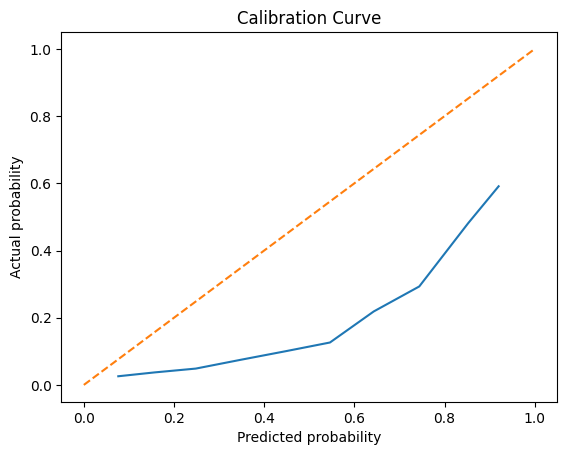

In [54]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve")

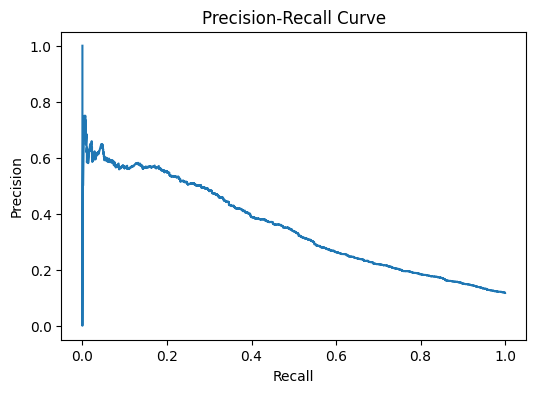

In [55]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()



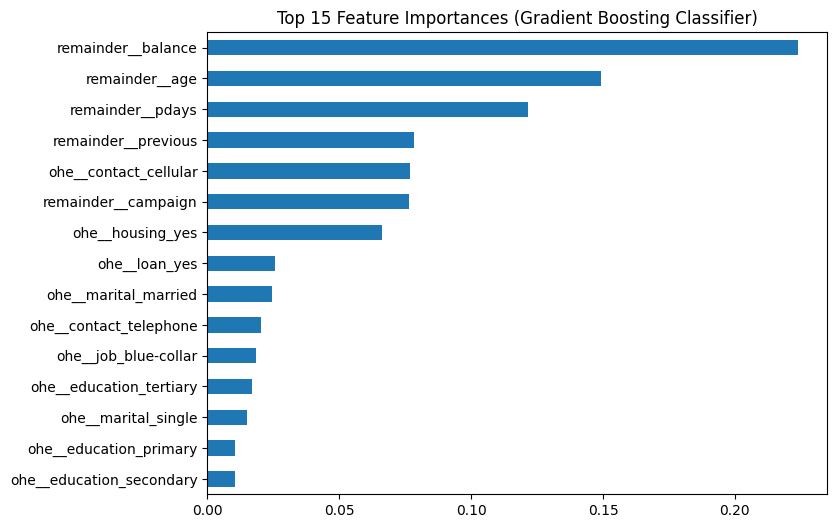

In [56]:
importances = pipe_gb.named_steps['gb_trf'].feature_importances_

feature_names = pipe_rf.named_steps['trf1'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances (Gradient Boosting Classifier)")
plt.gca().invert_yaxis()
plt.show()

## Data Leakage
- Duration column significantly affects the model that can result in data leakage
- So removing duration will be ideal

In [70]:
gb_trf.feature_importances_

array([0.01847072, 0.00942614, 0.0041169 , 0.00690165, 0.00886211,
       0.0052231 , 0.0076238 , 0.00639703, 0.0071566 , 0.00419651,
       0.02440161, 0.01517485, 0.00600406, 0.06607479, 0.0254275 ,
       0.07679945, 0.02040916, 0.01055226, 0.01041507, 0.01679488,
       0.14916755, 0.22392074, 0.07646329, 0.12159066, 0.07842957])

In [67]:
pickle.dump(pipe_gb,open('gb_pipeline.pkl','wb'))

In [58]:
from sklearn.cluster import KMeans
X = df.drop(columns=['y'])
numeric =X.select_dtypes(['int','float'])
cat =X.select_dtypes('object')
pipe_pre = Pipeline([
    ('trf1',transformer), #encoding
    ('sc',scaler) # model
    ])

In [59]:
X_scaled =pipe_pre.fit_transform(X)

In [60]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [61]:
inertia

[497320.9999999263,
 449935.68870567146,
 402108.15433475067,
 346605.60926375346,
 295283.71709742374,
 247223.68077513698,
 205411.0020259887,
 162142.7269733396,
 119472.00749536268]

In [62]:
kmeans=KMeans(n_clusters= 4,random_state=42)
clusters=kmeans.fit_predict(X_scaled)


In [63]:
kmeans.labels_

array([0, 0, 0, ..., 2, 3, 0], shape=(45211,), dtype=int32)

In [64]:
numeric['clusters']=clusters

In [65]:
numeric.groupby('clusters').mean()

,age,balance,campaign,pdays,previous
clusters,,,,,
0,40.105380,1400.038701,2.785895,38.904905,0.590484
1,26.542644,1388.060768,2.299574,57.041578,0.953092
2,61.626767,1984.215106,2.346731,37.443905,0.638693
3,40.261078,1098.760479,2.831138,43.370958,0.499800
